## 1. Data Loading and Exploration

### 1.1 Modules and Libraries

In [62]:
import numpy as np
import time
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

FOLDER_PATH = '/content/drive/MyDrive/Colab Notebooks/data_model_davies'

Mounted at /content/drive


### 1.2 Numerical Parameters

In [63]:
# Numerical parameters
nlat = 78
nlon = 71
nz = 500 # Initial number of rioters

Lr = 6 # most recent time steps in our discretised temporal scheme
Lp = 12 # response lag of the police units

Nt = 500 # Rate at which individuals choose to participate at time t
Ntt = 10

dt = 0.1 # delta time
sim_time = 0.0 # init time

### 1.3 Simulation Parameters

In [64]:
# Simulation parameters

# alpha_r: Attractiveness of a retail site to rioters (It is the parameter associated with the size of the retail location.)
# beta_r: Distance decay parameter for rioters (It influences how the distance between a rioter's residence and a potential
#         target affects the attractiveness of that target)
# gamma_r: Deterrent effect of police presence (It is a factor in the term that modifies the attractiveness of location j based
#          on the number of police officers and rioters, so it is a measure of how much the presence of police will deter a rioter)

alpha_r = 0.5
beta_r = 0.5
gamma_r = 0.11

mu = 1.0 # This is an exponent in the function for the probability of rioting in an area, related to how deprivation affects the likelihood of rioting

# alpha_p: Attractiveness of a location to police. It influences how police resources are allocated based on the characteristics of the location.
# gamma_p: Impact of the number of rioters on the police requirement at a site.

alpha_p = 1.0
gamma_p = 0.01

eta = 0.005 # Infection rate. It determines how quickly individuals are influenced by the ongoing disorder and become active rioters
tau = 0.75 # Arrest rate parameter. It determines how quickly rioters are arrested by police when they are present
Ptotal = 500.0  # Total number of police forces

### 1.4 Data Sources

In [65]:
# Data sources

# Initial data arrays
origin = np.loadtxt(f"{FOLDER_PATH}/origin_dens_500m_5am10am.dat") # Origin
destination = np.loadtxt(f"{FOLDER_PATH}/destination_dens_500m_5am10am.dat") # Destination

# i: Residential Área
# j: Retail Center (Potential Riot Site)
Zj = np.loadtxt(f"{FOLDER_PATH}/targets_500.dat")  # Targets (Benefit for j site is given by the logarithm of Zj a non-dimensional measure of its relative value)
dij = np.load(f"{FOLDER_PATH}/rij_500_no_network.npy")  # Ponderated distances (the distance between the centroids of i and j)
Dj_cl= np.loadtxt(f"{FOLDER_PATH}/data_sosafe.dat") # Data from SOSAFE (real data)

# Population, Police and Rioters
Ii = origin + destination  # Inactive population (the number of inactive individuals resident in area i)
Ai = np.zeros((nlat, nlon), "d")  # Active population
Ci = np.zeros((nlat, nlon), "d")  # Capture rate
rho = np.ones((nlat, nlon), "d")  # Deprivation distribution (is a measure of the deprivation in i)

Rj = np.zeros(nz, "d")  # Rioters (Ri: the number of rioters whose residece in in a given zone i)
# Rj = np.loadtxt('Rj_init.dat') # Initial 100 rioters distribution
Pj = np.zeros(nz, "d")  # Police officers
We_ij = np.zeros((nlat, nlon, nz), "d")  # Benefit computation (We_ij: effective attractiveness)
fjdel = np.zeros((nz, Lr), "d")  # Delayed effect computation
Sij = np.zeros((nlat, nlon, nz), "d")  # Population flow between i and j (An estimate of the number of rioters from i who are participating in disorder in j at time t)
Dj = np.zeros(nz, "d")  # The number of rioters in j
Ddel = np.zeros((nz, Lp), "d")  # Police requirement, time-delayed
Dej = np.zeros(nz, "d")

## 2. EDA and Plots

### 2.1 Origin Density 500m, 5am - 10am

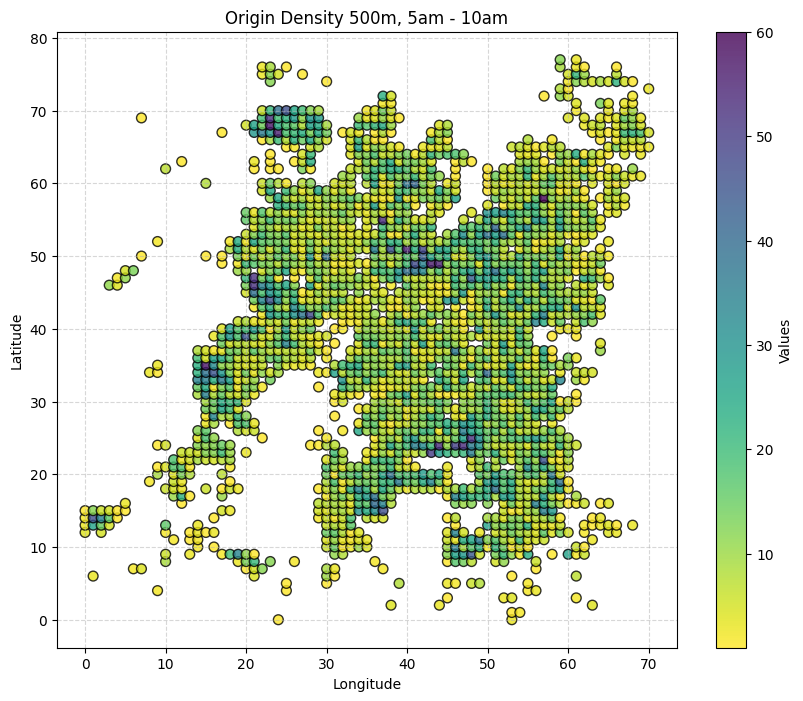

In [66]:
# # Figure Size
# plt.figure(figsize=(10, 8))

# # Get pos from not null values
# x, y = np.where(origin != 0)

# # Data viz
# plt.scatter (y, x, c=origin[x, y], cmap='viridis_r', s=50, edgecolor='k', alpha=0.8)
# plt.colorbar(label='Values')  # Barra de color para ver los valores
# plt.title('Origin Density 500m, 5am - 10am')
# plt.xlabel('Longitude')
# plt.ylabel('Latitude')
# plt.grid(True, linestyle='--', alpha=0.5)

# plt.show()

### 2.2 Destination Density 500m, 5am - 10am

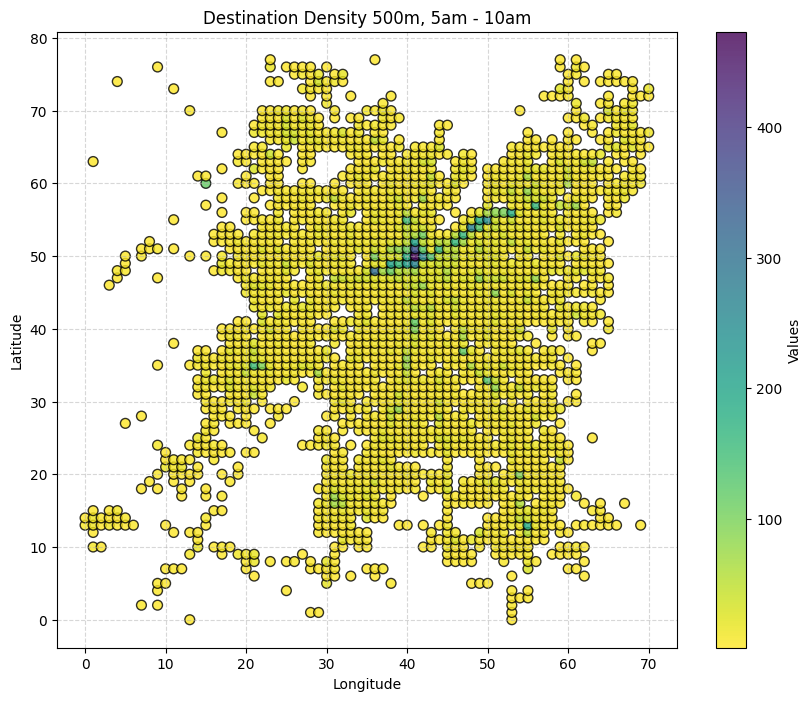

In [67]:
# # Figure Size
# plt.figure(figsize=(10, 8))

# # Get pos from not null values
# x, y = np.where(destination != 0)

# # Data viz
# plt.scatter(y, x, c=destination[x, y], cmap='viridis_r', s=50, edgecolor='k', alpha=0.8)
# plt.colorbar(label='Values')  # Color Bar
# plt.title('Destination Density 500m, 5am - 10am')
# plt.xlabel('Longitude')
# plt.ylabel('Latitude')
# plt.grid(True, linestyle='--', alpha=0.5)

# plt.show()

### 2.3 Rioter's Targets (Zj)

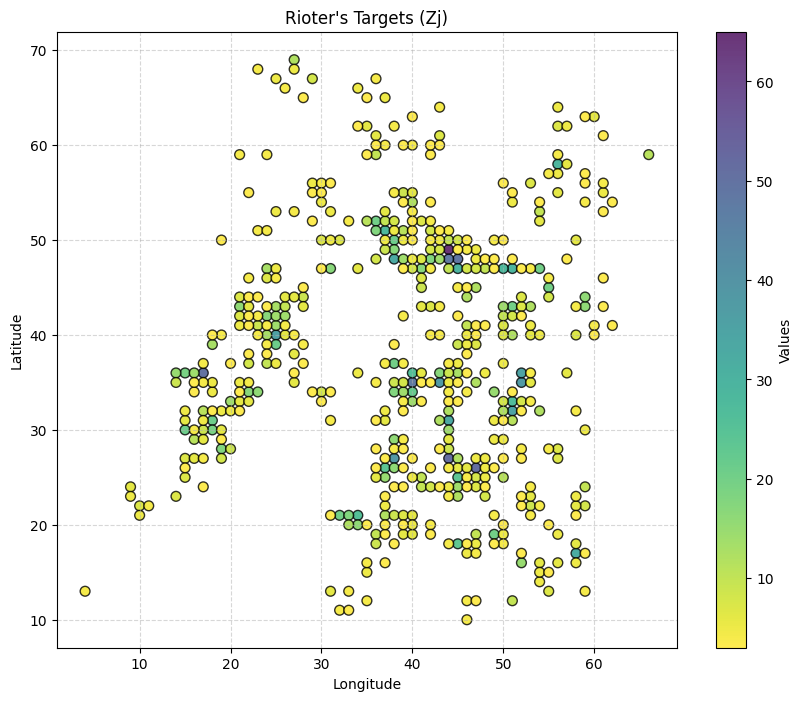

In [68]:
# # Get positions lat, lon
# # Convert Zj to NumPy array if it's a CuPy array
# Zj_np = Zj.get() if hasattr(Zj, 'get') else Zj
# lat, lon, values = Zj_np[:, 0], Zj_np[:, 1], Zj_np[:, 2]

# # Figure Size
# plt.figure(figsize=(10, 8))

# # Data viz
# plt.scatter(lon, lat, c=values, cmap='viridis_r', s=50, edgecolor='k', alpha=0.8)
# plt.colorbar(label='Values')  # Color Bar
# plt.title("Rioter's Targets (Zj)")
# plt.xlabel('Longitude')
# plt.ylabel('Latitude')
# plt.grid(True, linestyle='--', alpha=0.5)

# plt.show()

### 2.4 Rioter's Targets : SOSAFE (Dj_cl)

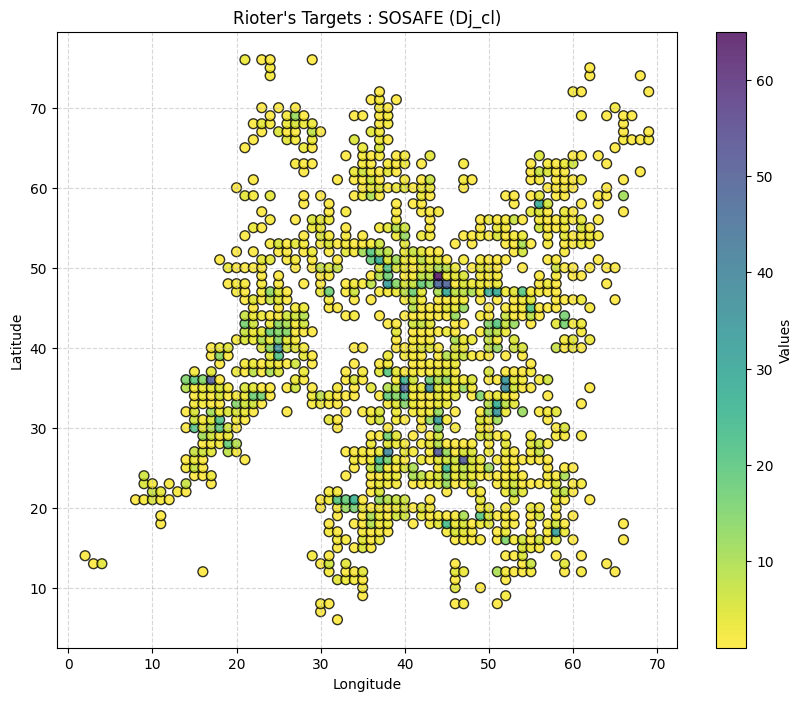

In [69]:
# # Crear una figura
# plt.figure(figsize=(10, 8))

# # Obtener las posiciones de los puntos (valores no ceros)
# x, y = np.where(Dj_cl != 0)

# # Visualizar los puntos
# plt.scatter(y, x, c=Dj_cl[x, y], cmap='viridis_r', s=50, edgecolor='k', alpha=0.8)
# plt.colorbar(label='Values')  # Barra de color para ver los valores
# plt.title("Rioter's Targets : SOSAFE (Dj_cl)")
# plt.xlabel('Longitude')
# plt.ylabel('Latitude')
# plt.grid(True, linestyle='--', alpha=0.5)

# # Mostrar el gráfico
# plt.show()


### 2.5 HeatMap - Rioter's Targets : SOSAFE (Dj_cl)

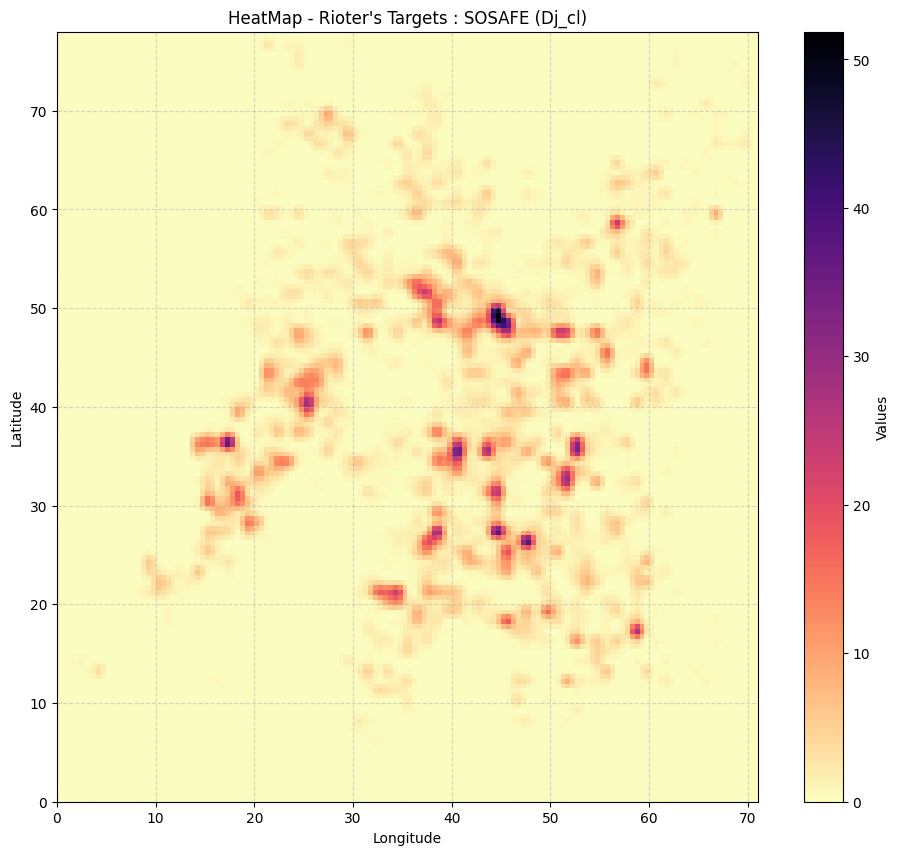

In [70]:
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter

def plot_heatmap():

    # Asumiendo que Dj_cl es tu matriz de datos original
    rows, cols = Dj_cl.shape

    # Crear coordenadas para los datos originales
    x = np.arange(cols)
    y = np.arange(rows)

    # Crear una función de interpolación
    f = RegularGridInterpolator((y, x), Dj_cl)

    # Crear una malla más fina
    x_new = np.linspace(0, cols-1, cols*2)
    y_new = np.linspace(0, rows-1, rows*2)
    xx, yy = np.meshgrid(x_new, y_new)

    # Interpolar
    pts = np.array([yy.flatten(), xx.flatten()]).T
    z = f(pts).reshape(xx.shape)

    # Aplicar suavizado gaussiano
    sigma = 0.05  # Ajusta este valor para controlar el grado de suavizado
    z_smooth = gaussian_filter(z, sigma=sigma)

    # Plotear
    plt.figure(figsize=(12, 10))
    plt.imshow(z_smooth, cmap='magma_r', extent=[0, cols, 0, rows], origin='lower')
    plt.colorbar(label='Values')  # Barra de color para ver los valores
    plt.title("HeatMap - Rioter's Targets : SOSAFE (Dj_cl)")
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid(True, linestyle='--', alpha=0.5)

plot_heatmap()

## 3. Simulation

### 3.1 Parameters Before Simulation

In [71]:
# # Computation loop
# counter = 0
# idxr = 0
# counterp = 0
# idxp = 0

# # Testing params
# Nt, Ntt = 500, 10
# # Nt = 500 # Rate at which individuals choose to participate at time t
# # Ntt = 10

# # Data sources
# Ii = origin + destination  # Inactive population (the number of inactive individuals resident in area i)
# dij = np.load(f"{FOLDER_PATH}/rij_500_no_network.npy")

# # Precalculated arrays
# Rj = np.zeros(nz, "d")
# Ai = np.zeros((nlat, nlon), "d")  # Active population
# Pj = np.zeros(nz, "d")  # Police officers
# Ci = np.zeros((nlat, nlon), "d")  # Capture rate
# fjdel = np.zeros((nz, Lr), "d")  # Delayed effect computation

# auxij1 = np.exp(-beta_r * dij)
# dij = 1.0 * Zj[:, 2] * auxij1 / np.max(Zj[:, 2])


# # alpha_r: Attractiveness of a retail site to rioters (It is the parameter associated with the size of the retail location.)
# # beta_r: Distance decay parameter for rioters (It influences how the distance between a rioter's residence and a potential
# #         target affects the attractiveness of that target)
# # gamma_r: Deterrent effect of police presence (It is a factor in the term that modifies the attractiveness of location j based
# #          on the number of police officers and rioters, so it is a measure of how much the presence of police will deter a rioter)

# alpha_r = 0.5
# beta_r = 0.5
# gamma_r = 0.11

# print(f"Before Sim Rj: {Rj.shape}")
# print(np.min(Rj), np.max(Rj),"\n")
# print(f"Before Sim Ai: {Ai.shape}")
# print(np.min(Ai), np.max(Ai),"\n")
# print(f"Before Sim Ii: {Ii.shape}")
# print(np.min(Ii), np.max(Ii),"\n")

### 3.2 Original Simulation

In [72]:
# # Computation loop
# counter = 0
# idxr = 0
# counterp = 0
# idxp = 0

# # Testing params
# Nt, Ntt = 10, 10
# Rj = np.zeros(nz, "d")

# # Precalculated arrays

# auxij1 = np.exp(-beta_r * dij)
# dij = 1.0 * Zj[:, 2] * auxij1 / np.max(Zj[:, 2])

# print("Starting loop ...")
# timer0 = time.time()
# t = 0

# for nn in range(Nt):
#     for mm in range(Ntt):

#         fj = np.exp(-np.floor(gamma_r * Pj / (Rj + 1.0e-20))) # 500 Values
#         Wij = fj * dij # Dj shape: 78, 71, 500 (Broadcasting) --> Attractiveness term ij
#         Wi = np.sum(Wij, axis=2) # Wi shape: 78, 71 each value is the sum of 500 values (fj) --> Attractiveness term i

#         P_off = rho * Wi / (1.0 + Wi) # P_off shape: 78, 71

#         # fjdel storage
#         idxr = counter - (Lr) * int(counter / Lr) # Lr: 6, idxr: 0-5
#         fjdel[:, idxr] = fj # fjdel: 500, 6

#         if counter >= Lr:
#             dnm = Lr
#         else:
#             dnm = counter + 1
#         # Delayed term computation
#         # print (f"Lr: {Lr}, idxr: {idxr}, dnm: {dnm}, counter: {counter}")
#         We_ij = np.sum(fjdel, axis=1) * dij / dnm

#         # Flow computation step 1i
#         auxw = Ai / (np.sum(We_ij, axis=2) + 1.0e-20)

#         # Flow computation step 2, this loop must be vectorized
#         # for jj in range(nz):
#         #     Sij[:, :, jj] = auxw[:, :] * We_ij[:, :, jj]

#         Sij = auxw[:, :, np.newaxis] * We_ij

#         # Rioter computation

#         Rj = np.sum(np.sum(Sij, axis=1), axis=0)

#         # Police Interaction
#         Dj[:] = Zj[:, 2] ** (alpha_p) * np.exp(gamma_p * Rj[:])

#         # Delayed term computation
#         idxp = counter - (Lp) * int(counter / Lp)
#         Ddel[:, idxp] = Dj[:]
#         if counter >= Lp:
#             dnm = Lp
#         else:
#             dnm = counter + 1

#         Dej = np.sum(Ddel, axis=1) / dnm
#         Pj = Ptotal * Dej / np.sum(Dej)
#         counter += 1

#         # Capture rate
#         fj = 1.0 - np.exp(-np.floor(Pj / (Rj + 1.0e-20)))
#         Ci = tau * np.sum(Sij * fj, axis=2)

#         # Time step for Ai and Ii
#         Ai += dt * (eta * P_off * Ii - Ci)
#         Ii += -dt * eta * P_off * Ii
#         t += dt

# timer1 = time.time()
# print("Total execution time: ", timer1 - timer0)

### 3.3 Optimazed Simulation

In [73]:
import cupy as cp

# Convertir todos los parámetros de tipo Numpy Array a CuPy Arrray antes del bucle
dij = cp.asarray(dij)
Zj = cp.asarray(Zj)
Rj = cp.asarray(Rj)
Pj = cp.asarray(Pj)
fjdel = cp.asarray(fjdel)
Ai = cp.asarray(Ai)
Ddel = cp.asarray(Ddel)
Ii = cp.asarray(Ii)
rho = cp.asarray(rho)
Dj = cp.asarray(Dj)

# Convertir escalares o parámetros adicionales a CuPy
beta_r = cp.float32(beta_r)  # Asegúrate de que sea un escalar de CuPy
gamma_r = cp.float32(gamma_r)
alpha_p = cp.float32(alpha_p)
gamma_p = cp.float32(gamma_p)
Ptotal = cp.float32(Ptotal)
dt = cp.float32(dt)
tau = cp.float32(tau)
eta = cp.float32(eta)  # Asegúrate de definir eta antes

print("Starting loop ...")
timer0 = time.time()
sim_time = cp.float32(0)
counter = 0

for nn in range(Nt):
    for mm in range(Ntt):
        fj = cp.exp(-cp.floor(gamma_r * Pj / (Rj + 1.0e-20)))

        Wij = fj * dij

        Wi = cp.sum(Wij, axis=2)

        P_off = rho * Wi / (1.0 + Wi)

        idxr = counter - (Lr) * int(counter / Lr)

        fjdel[:, idxr] = fj

        if counter >= Lr:
            dnm = Lr
        else:
            dnm = counter + 1

        We_ij = cp.sum(fjdel, axis=1) * dij / dnm

        auxw = Ai / (cp.sum(We_ij, axis=2) + 1.0e-20)

        Sij = auxw[:, :, cp.newaxis] * We_ij

        Rj = cp.sum(cp.sum(Sij, axis=1), axis=0)

        Dj[:] = Zj[:, 2] ** (alpha_p) * cp.exp(gamma_p * Rj[:])

        idxp = counter - (Lp) * int(counter / Lp)

        Ddel[:, idxp] = Dj[:]

        if counter >= Lp:
            dnm = Lp
        else:
            dnm = counter + 1

        Dej = cp.sum(Ddel, axis=1) / dnm

        Pj = Ptotal * Dej / cp.sum(Dej)

        counter += 1

        fj = 1.0 - cp.exp(-cp.floor(Pj / (Rj + 1.0e-20)))

        Ci = tau * cp.sum(Sij * fj, axis=2)

        Ai += dt * (eta * P_off * Ii - Ci)

        Ii += -dt * eta * P_off * Ii

        sim_time += dt

timer1 = time.time()
print("Total execution time: ", timer1 - timer0)

Starting loop ...
Total execution time:  6.957431316375732


### 3.4 Simulation with Print

In [74]:
# print("Starting loop ...")
# timer0 = time.time()
# sim_time = 0

# for nn in range(Nt):
#     for mm in range(Ntt):
#         print("=====================================")
#         print(f"nn: {nn}, mm: {mm}")
#         print("=====================================")

#         fj = np.exp(-np.floor(gamma_r * Pj / (Rj + 1.0e-20))) # 500 Values

#         print(f"fj: {fj.shape}")
#         print(np.min(fj), np.max(fj),"\n")

#         print(f"Rj: {Rj.shape}")
#         print(np.min(Rj), np.max(Rj),"\n")

#         print(f"Pj: {Pj.shape}")
#         print(np.min(Pj), np.max(Pj),"\n")


#         Wij = fj * dij # Dj shape: 78, 71, 500 (Broadcasting) --> Attractiveness term ij

#         print(f"dij: {dij.shape}")
#         print(np.min(dij), np.max(dij),"\n")

#         print(f"Wij: {Wij.shape}")
#         print(np.min(Wij), np.max(Wij),"\n")


#         Wi = np.sum(Wij, axis=2) # Wi shape: 78, 71 each value is the sum of 500 values (fj) --> Attractiveness term i

#         print(f"Wi: {Wi.shape}")
#         print(np.min(Wi), np.max(Wi),"\n")


#         P_off = rho * Wi / (1.0 + Wi) # P_off shape: 78, 71

#         print(f"P_off: {P_off.shape}")
#         print(np.min(P_off), np.max(P_off),"\n")


#         # # fjdel storage
#         idxr = counter - (Lr) * int(counter / Lr) # Lr: 6, idxr: 0-5

#         print(f"idxr: {idxr} \n")


#         fjdel[:, idxr] = fj # fjdel: 500, 6

#         print(f"fjdel: {fjdel.shape}")
#         print(np.min(fjdel), np.max(fjdel),"\n")


#         if counter >= Lr:
#             dnm = Lr
#         else:
#             dnm = counter + 1

#         print(f"Lr: {Lr} \n")
#         print(f"dnm: {dnm} \n")


#         # Delayed term computation
#         We_ij = np.sum(fjdel, axis=1) * dij / dnm

#         print(f"We_ij: {We_ij.shape}")
#         print(np.min(We_ij), np.max(We_ij),"\n")


#         # Flow computation step 1i
#         auxw = Ai / (np.sum(We_ij, axis=2) + 1.0e-20)

#         print(f"auxw: {auxw.shape}")
#         print(np.min(auxw), np.max(auxw),"\n")


#         # Flow computation step 2, this loop must be vectorized
#         # for jj in range(nz):
#         #     Sij[:, :, jj] = auxw[:, :] * We_ij[:, :, jj]

#         Sij = auxw[:, :, np.newaxis] * We_ij

#         print(f"nz: {nz} \n")
#         print(f"Sij: {Sij.shape}")
#         print(np.min(Sij), np.max(Sij),"\n")


#         # Rioter computation

#         Rj = np.sum(np.sum(Sij, axis=1), axis=0)

#         print(f"Rj: {Rj.shape}")
#         print(np.min(Rj), np.max(Rj),"\n")


#         # Police Interaction
#         Dj[:] = Zj[:, 2] ** (alpha_p) * np.exp(gamma_p * Rj[:])

#         print(f"Dj: {Dj.shape}")
#         print(np.min(Dj), np.max(Dj),"\n")

#         # Delayed term computation
#         idxp = counter - (Lp) * int(counter / Lp)

#         print(f"Lp: {Lp} \n")
#         print(f"idxp: {idxp} \n")


#         Ddel[:, idxp] = Dj[:]

#         print(f"Ddel: {Ddel.shape}")
#         print(np.min(Ddel), np.max(Ddel),"\n")


#         if counter >= Lp:
#             dnm = Lp
#         else:
#             dnm = counter + 1

#         print(f"Lp: {Lp} \n")
#         print(f"dnm: {dnm} \n")

#         Dej = np.sum(Ddel, axis=1) / dnm

#         print(f"Dej: {Dej.shape}")
#         print(np.min(Dej), np.max(Dej),"\n")


#         Pj = Ptotal * Dej / np.sum(Dej)

#         print(f"Pj: {Pj.shape}")
#         print(np.min(Pj), np.max(Pj),"\n")

#         # Counter
#         counter += 1
#         print(f"counter: {counter} \n")

#         # Capture rate
#         fj = 1.0 - np.exp(-np.floor(Pj / (Rj + 1.0e-20)))

#         print(f"fj: {fj.shape}")
#         print(np.min(fj), np.max(fj),"\n")


#         Ci = tau * np.sum(Sij * fj, axis=2)

#         print(f"Ci: {Ci.shape}")
#         print(np.min(Ci), np.max(Ci),"\n")

#         # Time step for Ai and Ii
#         Ai += dt * (eta * P_off * Ii - Ci)

#         print(f"Ai: {Ai.shape}")
#         print(np.min(Ai), np.max(Ai),"\n")


#         Ii += -dt * eta * P_off * Ii
#         print(f"Ii: {Ii.shape}")
#         print(np.min(Ii), np.max(Ii),"\n")

#         # Simulation Time
#         sim_time += dt

#         print(f"sim_time: {sim_time} \n")

# timer1 = time.time()
# print("Total execution time: ", timer1 - timer0)

## 4. Results

### 4.1 Data After Simulation

In [75]:
print(f"After Sim Rj: {Rj.shape}")
print(np.min(Rj), np.max(Rj),"\n")
print(f"After Sim Ai: {Ai.shape}")
print(np.min(Ai), np.max(Ai),"\n")
print(f"After Sim Ii: {Ii.shape}")
print(np.min(Ii), np.max(Ii),"\n")

After Sim Rj: (500,)
0.0 240.16224507932716 

After Sim Ai: (78, 71)
0.0 446.333379880819 

After Sim Ii: (78, 71)
0.0 39.982583791591274 



### 4.2 LinePlot: Comparison of Riot Targets: Simulation vs Zj (real values SOSAFE)

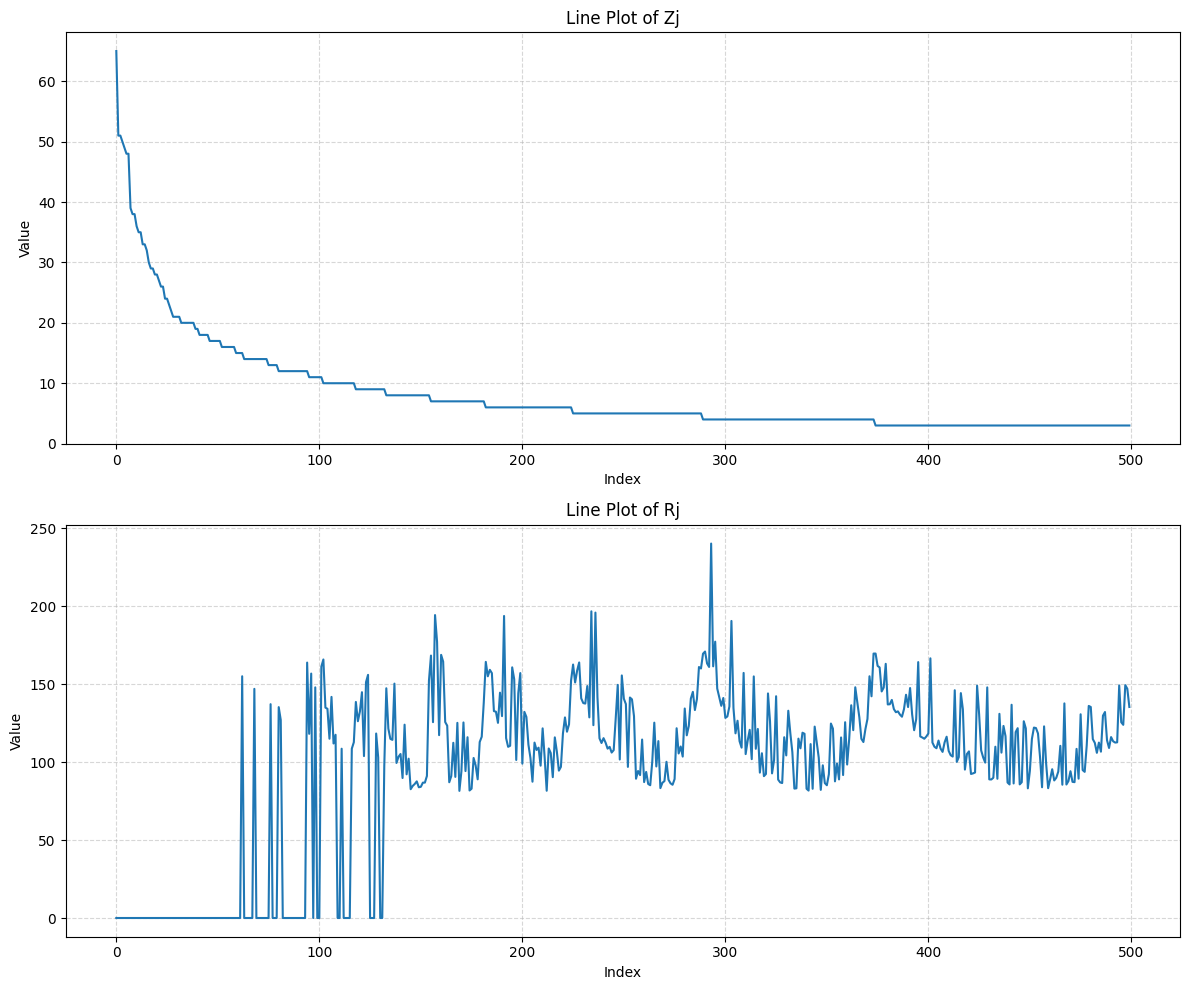

In [76]:
Zj_np = Zj.get() if hasattr(Zj, 'get') else Zj
Rj_plot = Rj.get() if hasattr(Rj, 'get') else Rj

# Crear una figura con dos subplots verticales
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Primer subplot para Zj
x1 = np.arange(len(Zj_np))
y1 = Zj_np[:, 2]
ax1.plot(x1, y1)
ax1.set_xlabel('Index')
ax1.set_ylabel('Value')
ax1.set_title('Line Plot of Zj')
ax1.grid(True, linestyle='--', alpha=0.5)

# Segundo subplot para Rj
x2 = np.arange(len(Rj_plot))
y2 = Rj_plot
ax2.plot(x2, y2)
ax2.set_xlabel('Index')
ax2.set_ylabel('Value')
ax2.set_title('Line Plot of Rj')
ax2.grid(True, linestyle='--', alpha=0.5)

# Ajustar el espaciado entre subplots
plt.tight_layout()

# Mostrar la figura
plt.show()

### 4.2 ScatterPlot: Comparison of Riot Targets: Simulation vs Zj (real values SOSAFE)

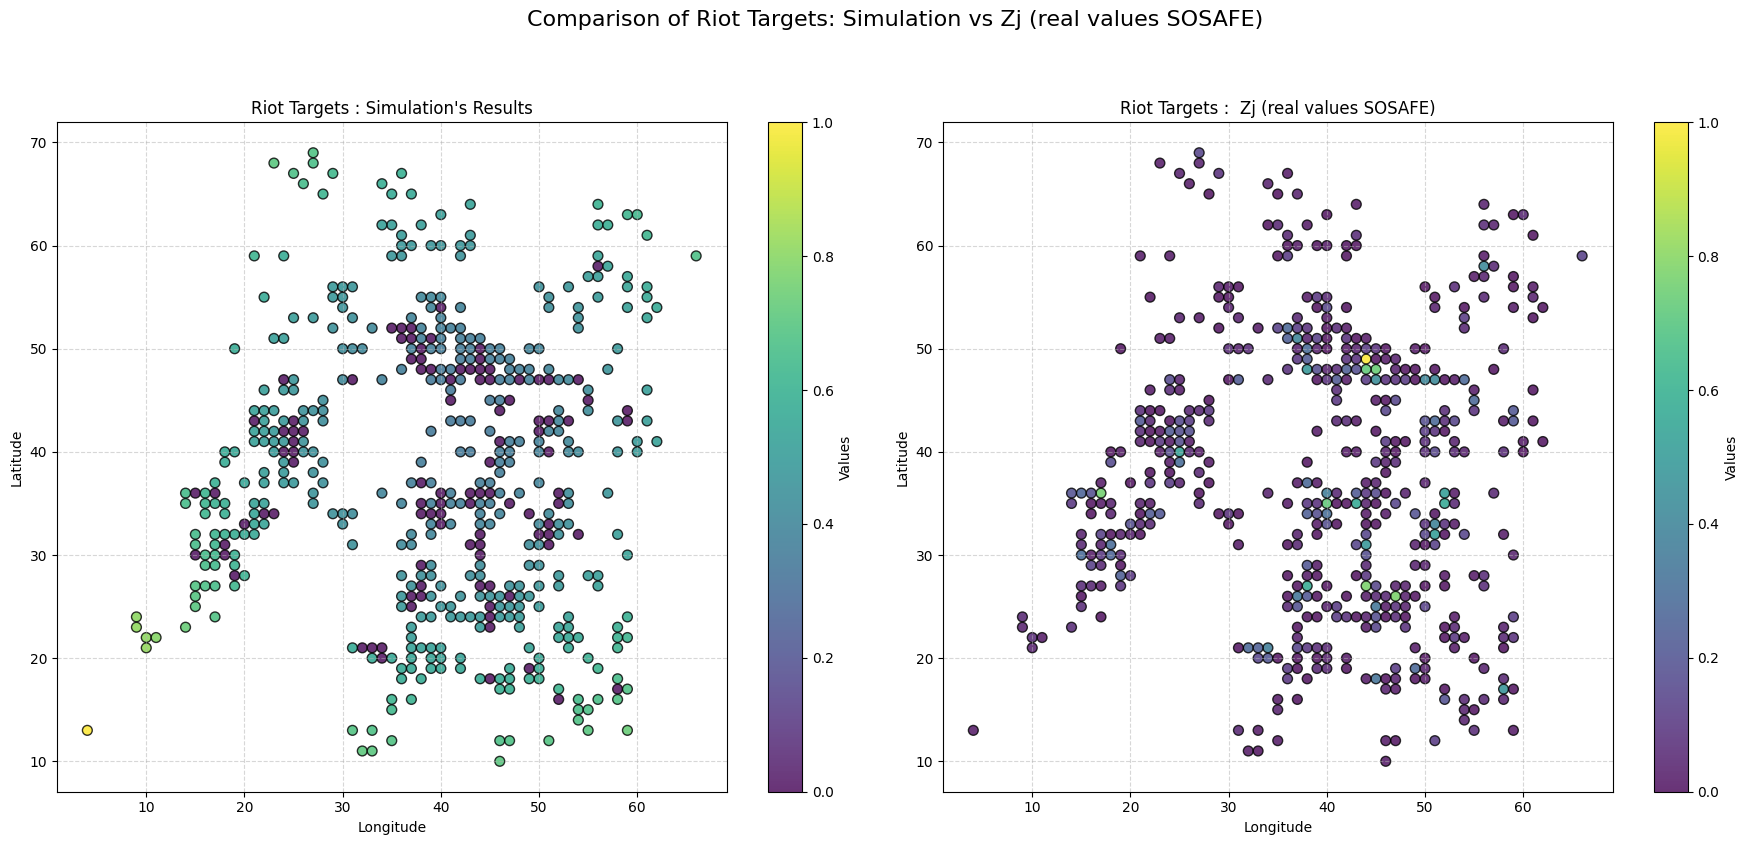

In [77]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Convertir de CuPy a Numpý
Rj = Rj.get() if hasattr(Rj, 'get') else Rj
Zj = Zj.get() if hasattr(Zj, 'get') else Zj

# Escalar resultados
scaled_results = scaler.fit_transform(Rj.reshape(-1, 1)) # (500, 1)

# Agregar coordenadas
latitude_simulation, longitude_simulation, values_simulation = Zj[:, 0], Zj[:, 1], scaled_results

# Escalar valores reales
scaled_real_values = scaler.fit_transform(Zj[:, 2].reshape(-1, 1))

# Crear una figura con dos subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

xlabel, ylabel = "Longitude", "Latitude"

# Agregar un título general
fig.suptitle("Comparison of Riot Targets: Simulation vs Zj (real values SOSAFE)", fontsize=16, y=1.05)

cmap_color = 'viridis'

# Subplot para Simulation's Results
sc1 = ax1.scatter(longitude_simulation, latitude_simulation, c=scaled_results, cmap=cmap_color, s=50, edgecolor='k', alpha=0.8)
ax1.set_title("Riot Targets : Simulation's Results")
ax1.set_xlabel(xlabel)
ax1.set_ylabel(ylabel)
ax1.grid(True, linestyle='--', alpha=0.5)

fig.colorbar(sc1, ax=ax1, label='Values')  # Barra de color para ver los valores

# Subplot para Dj_cl
sc2 = ax2.scatter(longitude_simulation, latitude_simulation, c=scaled_real_values, cmap=cmap_color, s=50, edgecolor='k', alpha=0.8)
ax2.set_title('Riot Targets :  Zj (real values SOSAFE)')
ax2.set_xlabel(xlabel)
ax2.set_ylabel(ylabel)
ax2.grid(True, linestyle='--', alpha=0.5)

fig.colorbar(sc2, ax=ax2, label='Values')  # Barra de color para ver los valores

# Mostrar el gráfico
plt.tight_layout()
plt.show()

### 4.3 Interpolation: Linear, Cubic and Polynomial

#### 4.3.1 Cubic Interporlation

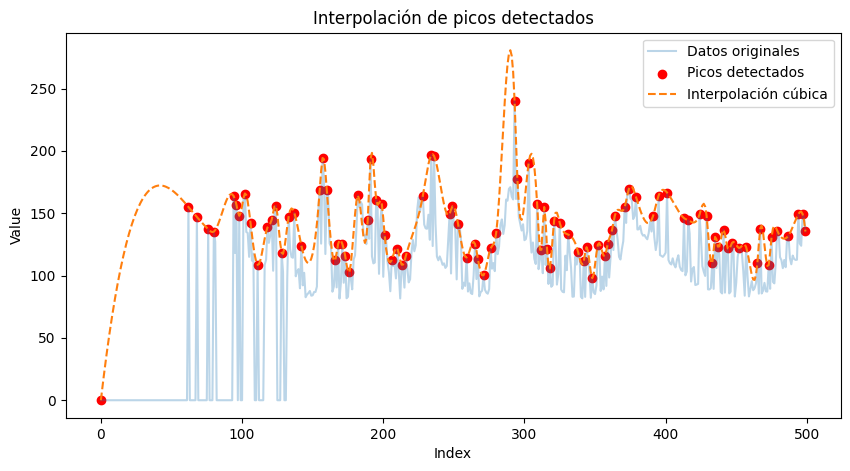

In [78]:
from scipy.signal import find_peaks
from scipy.interpolate import CubicSpline

# Datos simulados (reemplázalos con los tuyos)
x = np.arange(len(Rj_plot))
y = Rj_plot

# Detectar picos
y_norm = (y - np.min(y)) / (np.max(y) - np.min(y))  # Normalización Min-Max
peaks, _ = find_peaks(y_norm, prominence=0.05)  # Ajuste según la escala normalizada
peaks = np.insert(peaks, 0, 0)  # Asegurar que el primer punto sea considerado un pico
peaks = np.append(peaks, len(y)-1)  # Incluir el último punto también si es necesario

# Filtrar los valores
x_peaks = x[peaks]
y_peaks = y[peaks]

# Interpolación cúbica
cs = CubicSpline(x_peaks, y_peaks)

# Generar valores interpolados
cubic_interpolation_sim = cs(x)

# Graficar
plt.figure(figsize=(10, 5))
plt.plot(x, y, alpha=0.3, label="Datos originales")
plt.scatter(x_peaks, y_peaks, color="red", label="Picos detectados")
plt.plot(x, cubic_interpolation_sim, label="Interpolación cúbica", linestyle="--")
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Interpolación de picos detectados")
plt.legend()
plt.show()


#### 4.3.2 Linear Interporlation

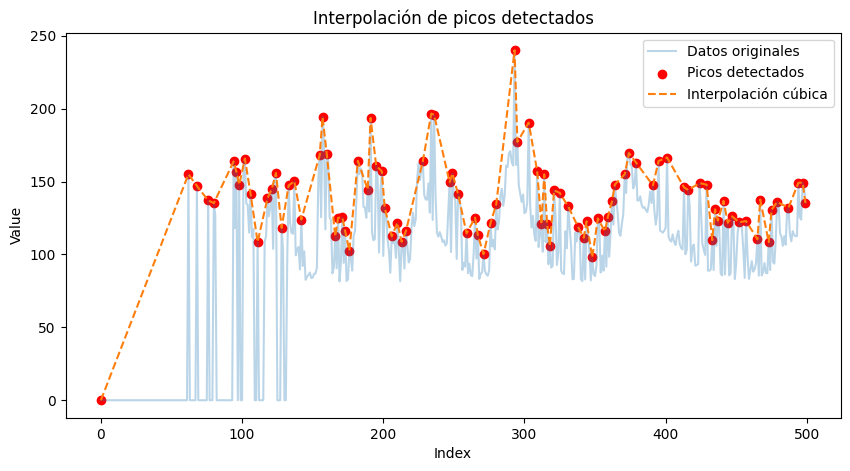

In [79]:
from scipy.signal import find_peaks

# Datos simulados (reemplázalos con los tuyos)
x = np.arange(len(Rj_plot))
y = Rj_plot

# Detectar picos
y_norm = (y - np.min(y)) / (np.max(y) - np.min(y))  # Normalización Min-Max
peaks, _ = find_peaks(y_norm, prominence=0.05)  # Ajuste según la escala normalizada
peaks = np.insert(peaks, 0, 0)  # Asegurar que el primer punto sea considerado un pico
peaks = np.append(peaks, len(y)-1)  # Incluir el último punto también si es necesario

# Filtrar los valores
x_peaks = x[peaks]
y_peaks = y[peaks]

# Interpolación lineal
linear_interpolation_sim = np.interp(x, x_peaks, y_peaks)

# Graficar
plt.figure(figsize=(10, 5))
plt.plot(x, y, alpha=0.3, label="Datos originales")
plt.scatter(x_peaks, y_peaks, color="red", label="Picos detectados")
plt.plot(x, linear_interpolation_sim, label="Interpolación cúbica", linestyle="--")
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Interpolación de picos detectados")
plt.legend()
plt.show()


#### 4.3.3 Polynomial Interporlation

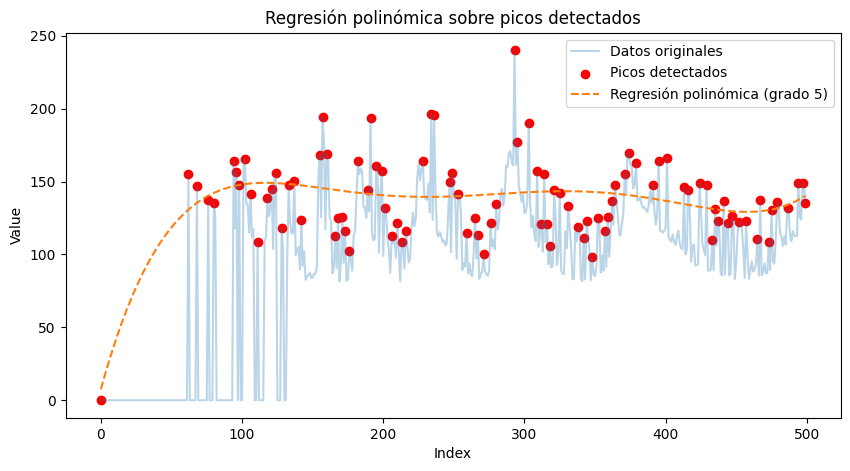

In [80]:
from scipy.signal import find_peaks
from numpy.polynomial.polynomial import Polynomial

# Datos simulados (reemplázalos con los tuyos)
x = np.arange(len(Rj_plot))
y = Rj_plot

# Detectar picos
y_norm = (y - np.min(y)) / (np.max(y) - np.min(y))  # Normalización Min-Max
peaks, _ = find_peaks(y_norm, prominence=0.05)  # Ajuste según la escala normalizada
peaks = np.insert(peaks, 0, 0)  # Incluir el primer punto como pico
peaks = np.append(peaks, len(y)-1)  # Incluir el último punto también si es necesario

# Filtrar los valores
x_peaks = x[peaks]
y_peaks = y[peaks]

# Ajustar una regresión polinómica
grado_polinomio = min(len(x_peaks)-1, 5)  # Máximo grado permitido es n-1
coeficientes = np.polyfit(x_peaks, y_peaks, grado_polinomio)
polinomio = np.poly1d(coeficientes)

# Evaluar el polinomio en los valores de x
polynomial_reg_sim = polinomio(x)

# Graficar
plt.figure(figsize=(10, 5))
plt.plot(x, y, alpha=0.3, label="Datos originales")
plt.scatter(x_peaks, y_peaks, color="red", label="Picos detectados")
plt.plot(x, polynomial_reg_sim, label=f"Regresión polinómica (grado {grado_polinomio})", linestyle="--")
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Regresión polinómica sobre picos detectados")
plt.legend()
plt.show()

#### 4.3.4 Comparison Interpolations

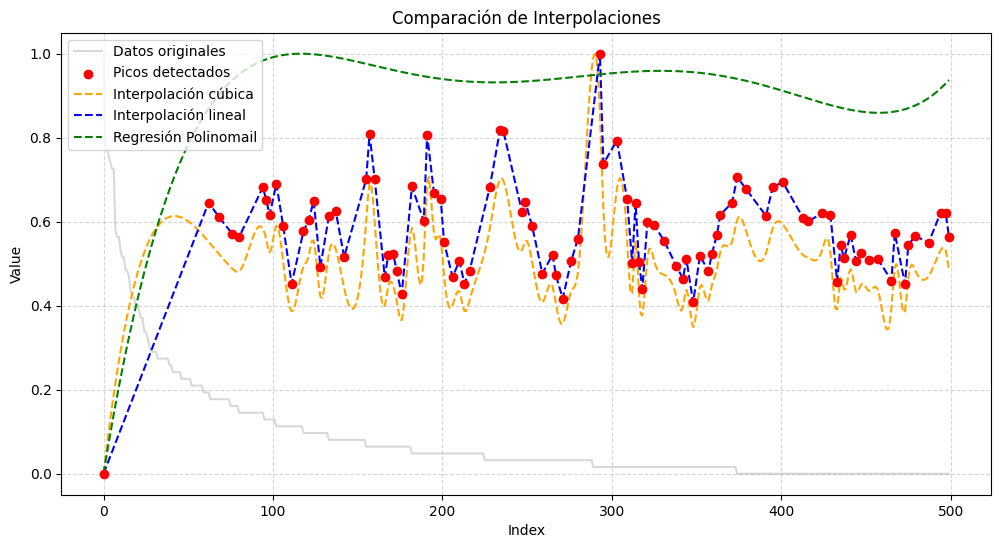

In [81]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_simulation_results_cubic = scaler.fit_transform(cubic_interpolation_sim.reshape(-1, 1)).flatten()
scaled_simulation_results_linear = scaler.fit_transform(linear_interpolation_sim.reshape(-1, 1)).flatten()
scaled_simulation_results_polynomial = scaler.fit_transform(polynomial_reg_sim.reshape(-1, 1)).flatten()

# Crear gráfico comparativo
plt.figure(figsize=(12, 6))
plt.plot(x, scaled_real_values, alpha=0.3, label="Datos originales", color="gray")
plt.scatter(x_peaks, scaler.fit_transform(y_peaks.reshape(-1, 1)), color="red", label="Picos detectados", zorder=3)
plt.plot(x, scaled_simulation_results_cubic, '--', label="Interpolación cúbica", color="orange")
plt.plot(x, scaled_simulation_results_linear, '--', label="Interpolación lineal", color="blue")
plt.plot(x, scaled_simulation_results_polynomial, '--', label="Regresión Polinomail", color="green")

# Etiquetas y leyenda
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Comparación de Interpolaciones")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

# Mostrar gráfico
plt.show()

In [82]:
import pandas as pd
import seaborn as sns

no_binary_col = ["linear interpolation", "cubic interpolation", "polynomial interpolation"]
df_interpolation = pd.DataFrame({
    "linear interpolation": scaled_simulation_results_linear,
    "cubic interpolation": scaled_simulation_results_cubic,
    "polynomial interpolation": scaled_simulation_results_polynomial,
    "real values": scaled_real_values.flatten()
})

df_interpolation

,linear interpolation,cubic interpolation,polynomial interpolation,real values
0,0.000000,0.000000,0.000000,1.000000
1,0.010412,0.034327,0.024640,0.774194
2,0.020825,0.067434,0.048834,0.774194
3,0.031237,0.099342,0.072589,0.758065
4,0.041650,0.130070,0.095908,0.741935
...,...,...,...,...
495,0.621395,0.537412,0.920834,0.000000
496,0.621664,0.538709,0.924746,0.000000
497,0.621932,0.532057,0.928811,0.000000
498,0.592730,0.514252,0.933031,0.000000


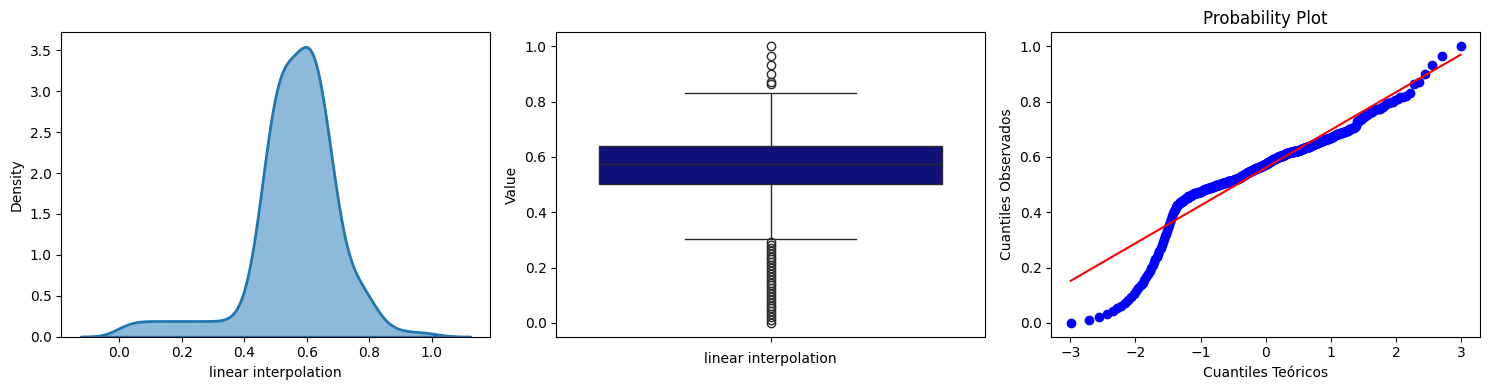

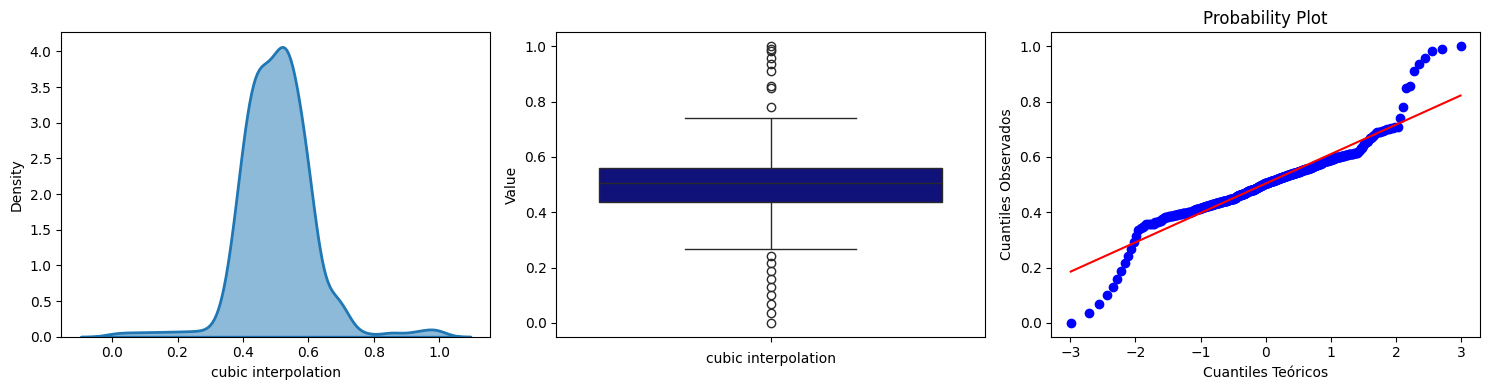

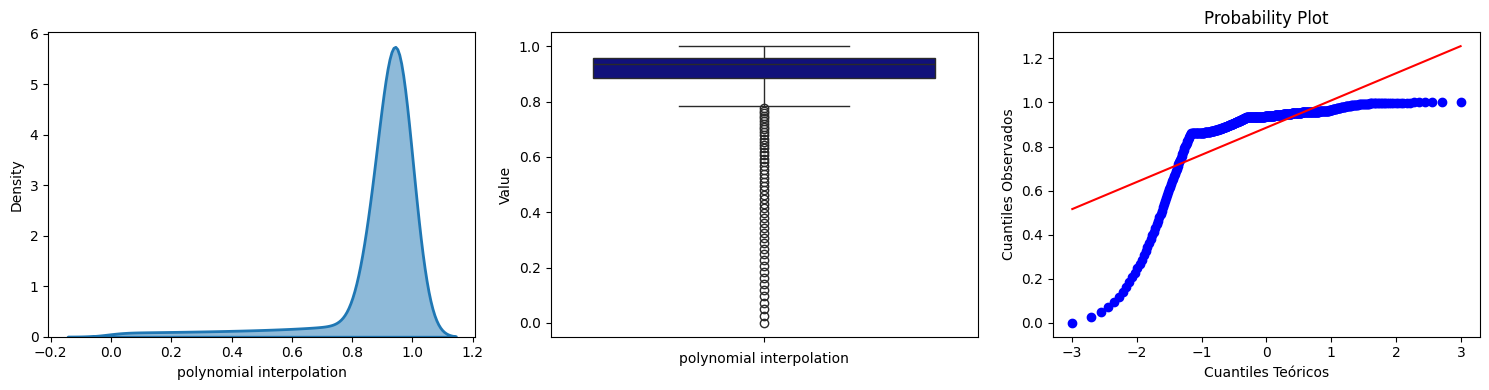

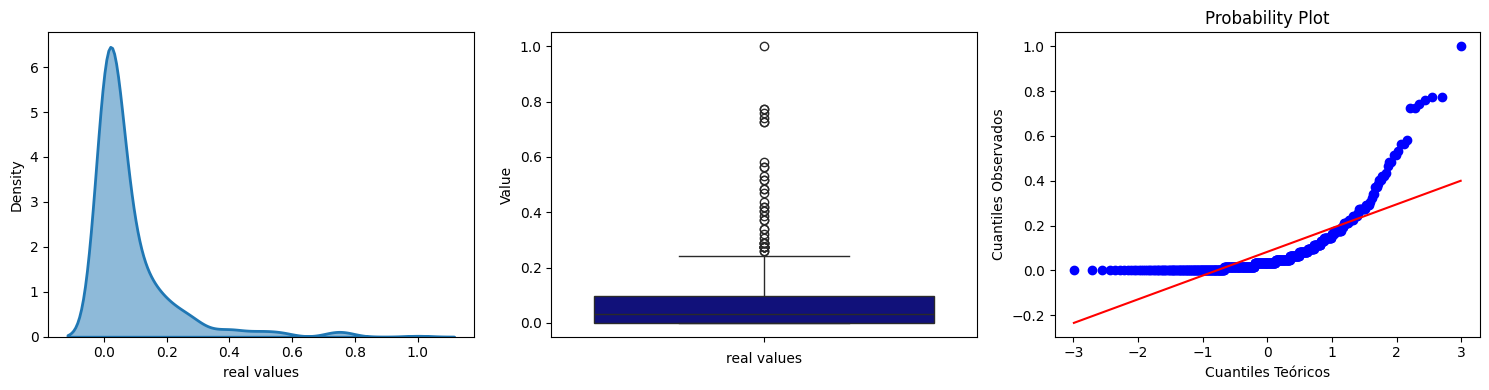

In [83]:
from scipy.stats import probplot

def plot_hist_box_probplot(df):

    for col in df.columns:  # type: ignore

        plt.figure(figsize=(15, 4))

        if len(df[col].unique()) > 20:  # type: ignore
            plt.subplot(1, 3, 1)
            sns.kdeplot(data=df, x=col, fill=True, alpha=0.5, linewidth=2)  # type: ignore
            plt.xlabel(col)
            plt.ylabel("Density")
        else:
            plt.subplot(1, 3, 1)
            sns.histplot(df[col], bins=30, color="skyblue")  # type: ignore
            plt.xlabel(col)
            plt.ylabel("Frequency")


        plt.subplot(1, 3, 2)
        sns.boxplot(data=df[col], color="darkblue")  # type: ignore
        plt.xlabel(col)
        plt.ylabel("Value")

        plt.subplot(1, 3, 3)
        probplot(x=df[col], plot=plt)  # type: ignore
        plt.xlabel("Cuantiles Teóricos")
        plt.ylabel("Cuantiles Observados")


        plt.tight_layout()

        plt.show()

plot_hist_box_probplot(df_interpolation)

### 4.4 ScatterPlot (Interpolated Data): Comparison of Riot Targets: Simulation vs Zj (real values SOSAFE)

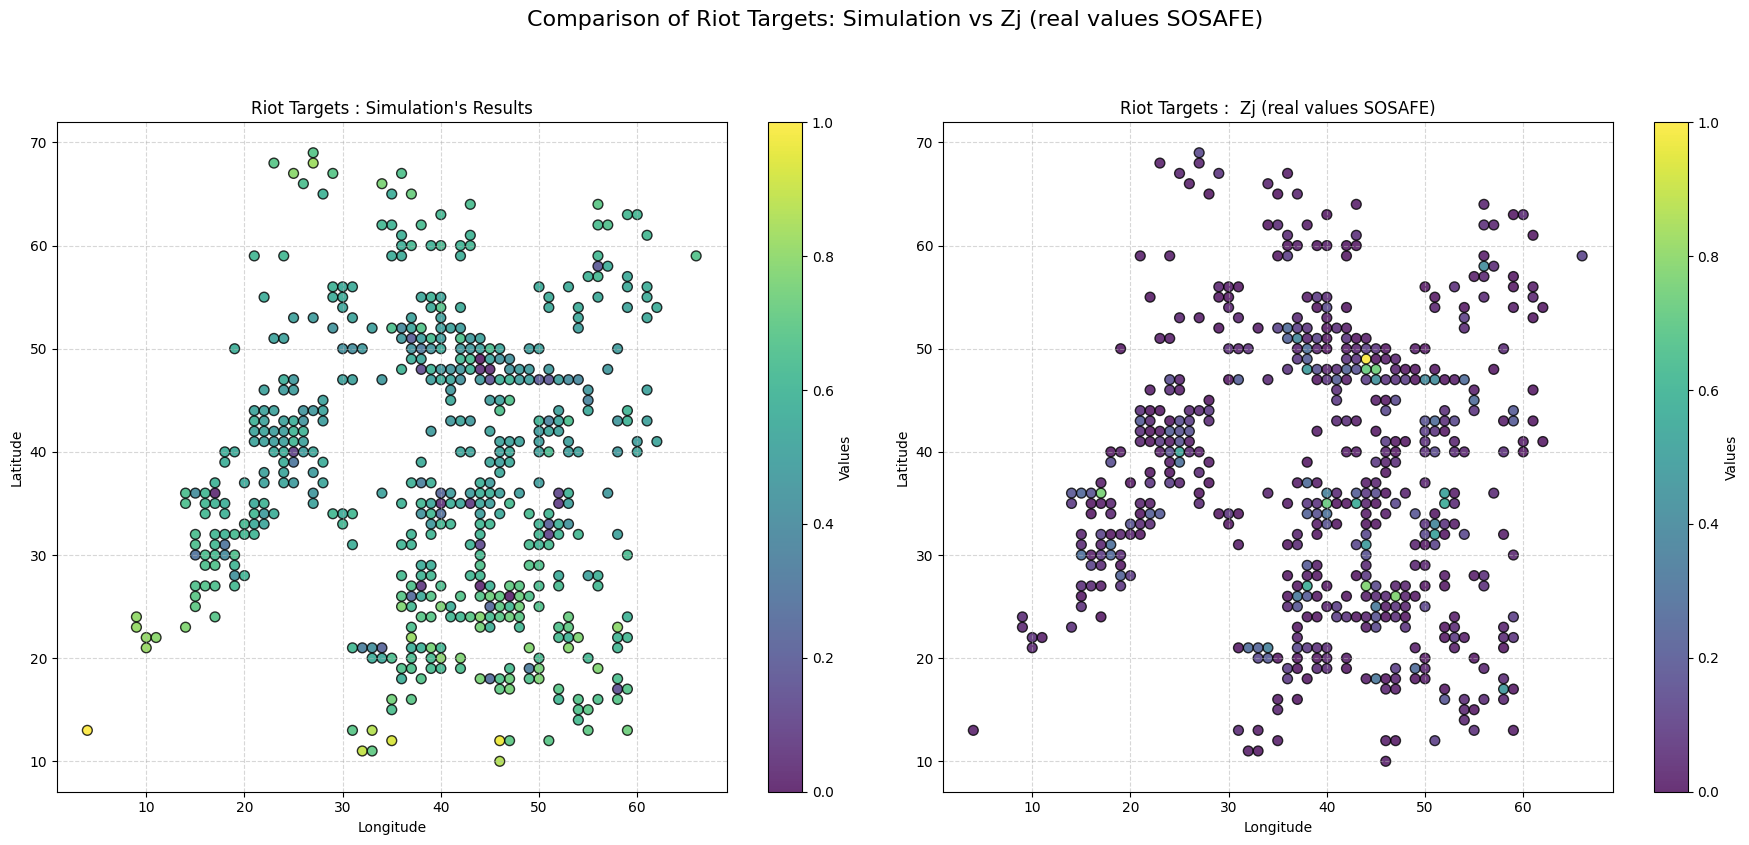

In [84]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# # Convertir de CuPy a Numpý
Rj = Rj.get() if hasattr(Rj, 'get') else Rj
Zj = Zj.get() if hasattr(Zj, 'get') else Zj

# # Agregar coordenadas
latitude_simulation, longitude_simulation = Zj[:, 0], Zj[:, 1]

# # Escalar valores reales
scaled_real_values = scaler.fit_transform(Zj[:, 2].reshape(-1, 1))

# Crear una figura con dos subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

xlabel, ylabel = "Longitude", "Latitude"

# Agregar un título general
fig.suptitle("Comparison of Riot Targets: Simulation vs Zj (real values SOSAFE)", fontsize=16, y=1.05)

cmap_color = 'viridis'

# Subplot para Simulation's Results
sc1 = ax1.scatter(longitude_simulation, latitude_simulation, c=scaled_simulation_results_linear, cmap=cmap_color, s=50, edgecolor='k', alpha=0.8)
ax1.set_title("Riot Targets : Simulation's Results")
ax1.set_xlabel(xlabel)
ax1.set_ylabel(ylabel)
ax1.grid(True, linestyle='--', alpha=0.5)

fig.colorbar(sc1, ax=ax1, label='Values')  # Barra de color para ver los valores

# Subplot para Dj_cl
sc2 = ax2.scatter(longitude_simulation, latitude_simulation, c=scaled_real_values, cmap=cmap_color, s=50, edgecolor='k', alpha=0.8)
ax2.set_title('Riot Targets :  Zj (real values SOSAFE)')
ax2.set_xlabel(xlabel)
ax2.set_ylabel(ylabel)
ax2.grid(True, linestyle='--', alpha=0.5)

fig.colorbar(sc2, ax=ax2, label='Values')  # Barra de color para ver los valores

# Mostrar el gráfico
plt.tight_layout()
plt.show()

### 4.5 HeatMap (Interpolated Data): Comparison of Riot Targets: Simulation vs Zj (real values SOSAFE)

In [85]:
import pandas as pd

Rj_sim = np.column_stack((Zj[:, 0], Zj[:, 1], scaled_simulation_results_linear))

# Obtener valores únicos ordenados de latitud y longitud
lat_unique = np.linspace(Rj_sim[:, 0].min(), Rj_sim[:, 0].max(), 78)  # 78 filas
lon_unique = np.linspace(Rj_sim[:, 1].min(), Rj_sim[:, 1].max(), 71)  # 71 columnas

# Crear DataFrame con los datos originales
df = pd.DataFrame(Rj_sim, columns=["lat", "lon", "value"])

# Crear la grilla vacía con ceros
grid = np.zeros((78, 71))

# Asignar valores a la grilla
for _, row in df.iterrows():
    lat_idx = np.abs(lat_unique - row["lat"]).argmin()  # Buscar índice más cercano
    lon_idx = np.abs(lon_unique - row["lon"]).argmin()
    grid[lat_idx, lon_idx] = row["value"]

# Ahora `grid` tiene la forma (78, 71) con los datos mapeados
print(grid.shape)  # (78, 71)

Rj_sim_data = grid

(78, 71)


In [86]:
Zj_real = np.column_stack((Zj[:, 0], Zj[:, 1], scaled_real_values))

# Obtener valores únicos ordenados de latitud y longitud
lat_unique = np.linspace(Zj_real[:, 0].min(), Zj_real[:, 0].max(), 78)  # 78 filas
lon_unique = np.linspace(Zj_real[:, 1].min(), Zj_real[:, 1].max(), 71)  # 71 columnas

# Crear DataFrame con los datos originales
df = pd.DataFrame(Zj_real, columns=["lat", "lon", "value"])

# Crear la grilla vacía con ceros
grid = np.zeros((78, 71))

# Asignar valores a la grilla
for _, row in df.iterrows():
    lat_idx = np.abs(lat_unique - row["lat"]).argmin()  # Buscar índice más cercano
    lon_idx = np.abs(lon_unique - row["lon"]).argmin()
    grid[lat_idx, lon_idx] = row["value"]

# Ahora `grid` tiene la forma (78, 71) con los datos mapeados
print(grid.shape)  # (78, 71)

Zj_real_data = grid

(78, 71)


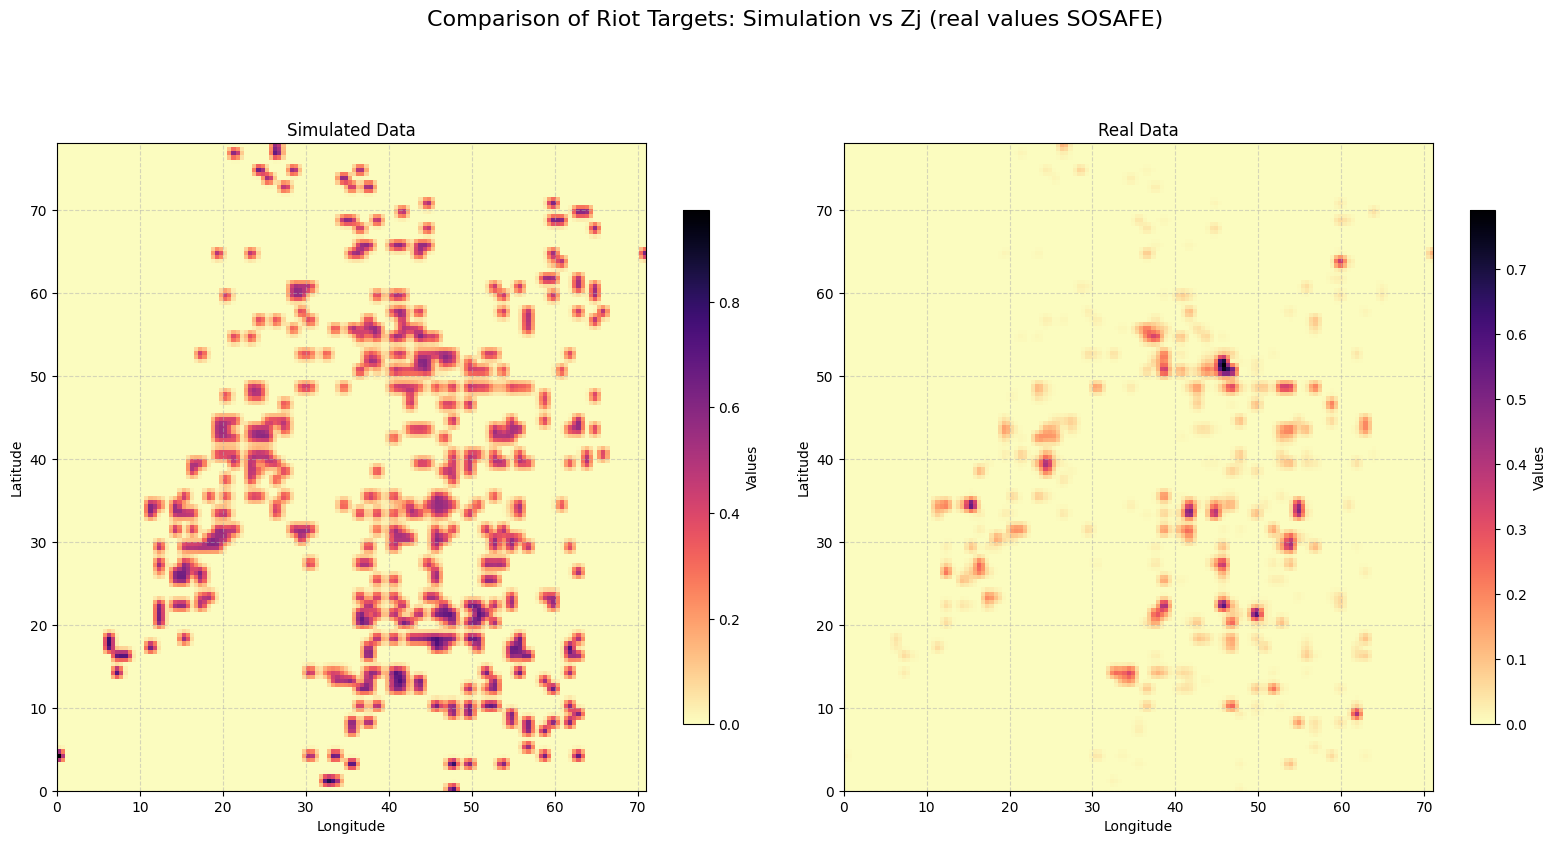

In [57]:
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter

def plot_combined_heatmaps(Rj_sim_data, Zj_real_data):
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))  # 1 fila, 2 columnas

    # Agregar un título general
    fig.suptitle("Comparison of Riot Targets: Simulation vs Zj (real values SOSAFE)", fontsize=16, y=1.05)

    datasets = [("Simulated Data", Rj_sim_data), ("Real Data", Zj_real_data)]

    for ax, (title, data) in zip(axes, datasets):
        rows, cols = data.shape

        # Crear coordenadas para los datos originales
        x = np.arange(cols)
        y = np.arange(rows)

        # Crear una función de interpolación
        f = RegularGridInterpolator((y, x), data)

        # Crear una malla más fina
        x_new = np.linspace(0, cols - 1, cols * 2)
        y_new = np.linspace(0, rows - 1, rows * 2)
        xx, yy = np.meshgrid(x_new, y_new)

        # Interpolar
        pts = np.array([yy.flatten(), xx.flatten()]).T
        z = f(pts).reshape(xx.shape)

        # Aplicar suavizado gaussiano
        sigma = 0.05  # Ajusta este valor según el nivel de suavizado deseado
        z_smooth = gaussian_filter(z, sigma=sigma)

        # Plotear en el subplot correspondiente
        im = ax.imshow(z_smooth, cmap='magma_r', extent=[0, cols, 0, rows], origin='lower')
        ax.set_title(title)
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        ax.grid(True, linestyle='--', alpha=0.5)

        # Agregar barra de color a cada mapa
        cbar = fig.colorbar(im, ax=ax, shrink=0.7)
        cbar.set_label('Values')

    plt.tight_layout()
    plt.show()

# Llamar a la función con tus datos
plot_combined_heatmaps(Rj_sim_data, Zj_real_data)


## 5. Metrics

In [58]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calculate_errors_sklearn(predicted, real):
    predicted = predicted.flatten()
    real = real.flatten()

    mse = mean_squared_error(real, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(real, predicted)
    r2 = r2_score(real, predicted)

    # MAPE con manejo de valores cero
    # Calculamos MAPE solo para valores no cero
    non_zero_mask = (real != 0)
    if np.any(non_zero_mask):
        mape = np.mean(np.abs((real[non_zero_mask] - predicted[non_zero_mask]) / real[non_zero_mask])) * 100
    else:
        mape = np.nan  # o podrías establecer otro valor por defecto

    # SMAPE (Symmetric Mean Absolute Percentage Error)
    epsilon = 1e-10
    smape = np.mean(2 * np.abs(real - predicted) / (np.abs(real) + np.abs(predicted) + epsilon)) * 100

    metrics = {
        "rmse": rmse,
        "mae": mae,
        "mape": mape,
        "smape": smape,
        "r2": r2,
        "max_error": np.max(np.abs(real - predicted))
    }

    return metrics

def print_detailed_comparison_sklearn(predicted, real):
    metrics = calculate_errors_sklearn(predicted, real)

    print("Métricas de error:")
    print(f"RMSE: {metrics['rmse']:.4f}")
    print(f"MAE: {metrics['mae']:.4f}")
    print(f"MAPE mod: {metrics['mape']:.2f}%")
    print(f"SMAPE: {metrics['smape']:.2f}%")
    print(f"R² Score: {metrics['r2']:.4f}")
    print(f"Error máximo: {metrics['max_error']:.4f}")


In [59]:
print("Interpolación Lineal")
print_detailed_comparison_sklearn(scaled_simulation_results_linear, scaled_real_values)
print("\n")
print("Interpolación Cúbica")
print_detailed_comparison_sklearn(scaled_simulation_results_cubic, scaled_real_values)
print("\n")
print("Regresión Polinomial")
print_detailed_comparison_sklearn(scaled_simulation_results_polynomial, scaled_real_values)

Interpolación Lineal
Métricas de error:
RMSE: 0.5419
MAE: 0.5208
MAPE mod: 1444.87%
SMAPE: 163.51%
R² Score: -15.4578
Error máximo: 1.0000


Interpolación Cúbica
Métricas de error:
RMSE: 0.4657
MAE: 0.4477
MAPE mod: 1237.15%
SMAPE: 159.45%
R² Score: -11.1507
Error máximo: 1.0000


Regresión Polinomial
Métricas de error:
RMSE: 0.8538
MAE: 0.8337
MAPE mod: 2330.23%
SMAPE: 171.99%
R² Score: -39.8472
Error máximo: 1.0000


In [60]:
!lscpu

Architecture:             x86_64
  CPU op-mode(s):         32-bit, 64-bit
  Address sizes:          46 bits physical, 48 bits virtual
  Byte Order:             Little Endian
CPU(s):                   12
  On-line CPU(s) list:    0-11
Vendor ID:                GenuineIntel
  Model name:             Intel(R) Xeon(R) CPU @ 2.20GHz
    CPU family:           6
    Model:                85
    Thread(s) per core:   2
    Core(s) per socket:   6
    Socket(s):            1
    Stepping:             7
    BogoMIPS:             4400.45
    Flags:                fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge m
                          ca cmov pat pse36 clflush mmx fxsr sse sse2 ss ht sysc
                          all nx pdpe1gb rdtscp lm constant_tsc rep_good nopl xt
                          opology nonstop_tsc cpuid tsc_known_freq pni pclmulqdq
                           ssse3 fma cx16 pcid sse4_1 sse4_2 x2apic movbe popcnt
                           aes xsave avx f16c rdrand hyperviso

In [61]:
!nvidia-smi

Sun Jul 13 16:18:24 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P0             52W /  400W |     647MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----